# Sentiment Analysis and Text Mining of Amazon Product Reviews

**Course:** BAN200 – Text Mining and Sentiment Analysis  
**Student:** Samuel Tsegay  
**Group Size:** Independent Project  
**Dataset Source:** Amazon Product Reviews Dataset, Kaggle  

## Project Objective

This project analyzes Amazon customer reviews using text mining and sentiment analysis techniques. The purpose is to identify patterns in customer opinions, measure customer satisfaction, and determine how review text can support product improvement and business decision-making.

## Main Business Question

How can sentiment analysis of Amazon customer reviews help businesses identify customer satisfaction, common product concerns, and opportunities for product improvement?

## 1. Import Required Libraries

This section imports the Python libraries required for data loading, data manipulation, text processing, and visualization throughout the project.

In [1]:
# ==========================================
# BAN200 - Amazon Product Reviews Project
# Section 1: Import Required Libraries
# ==========================================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Regular expressions for text cleaning
import re

# Natural Language Toolkit
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Display options
pd.set_option('display.max_columns', None)

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 2. Load the Dataset

This section uploads the Amazon Product Reviews dataset into Google Colab and loads it into a Pandas DataFrame for analysis.

In [3]:
# ==========================================
# Section 2: Upload and Load the Dataset
# ==========================================

from google.colab import files

uploaded = files.upload()

Saving amazon_product_reviews.csv to amazon_product_reviews.csv


In [4]:
# ==========================================
# Section 3: Read the Dataset
# ==========================================

# Read the CSV file into a Pandas DataFrame
df = pd.read_csv("amazon_product_reviews.csv")

# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display the first five rows
df.head()

Dataset Shape: (1597, 27)


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,manufacturer,manufacturerNumber,name,prices,reviews.date,reviews.doRecommend,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-08-08T00:00:00.000Z,NaN,139.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-09-01T00:00:00.000Z,NaN,126.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2015-07-20T00:00:00.000Z,NaN,69.0,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2017-06-16T00:00:00.000Z,NaN,2.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,NaN,Kindle Paperwhite,"[{""amountMax"":139.99,""amountMin"":139.99,""curre...",2016-08-11T00:00:00.000Z,NaN,17.0,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


## 4. Dataset Inspection

Before cleaning and preprocessing the dataset, it is important to inspect its structure, data types, and available variables. This helps identify which columns are relevant for sentiment analysis and whether any missing values need to be addressed.

In [5]:
# ==========================================
# Section 4: Dataset Inspection
# ==========================================

# Display dataset information
print("Dataset Information")
print("=" * 50)
df.info()

print("\n")

# Display all column names
print("Column Names")
print("=" * 50)

for column in df.columns:
    print(column)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  r

## 5. Select Relevant Variables

The original dataset contains several product-related and administrative variables that are not required for this analysis. This section selects only the variables that are directly relevant to sentiment analysis and the project's business question.

In [6]:
# ==========================================
# Section 5: Select Relevant Variables
# ==========================================

# Keep only the columns required for analysis
reviews_df = df[[
    "name",
    "reviews.title",
    "reviews.text",
    "reviews.rating",
    "reviews.doRecommend"
]].copy()

# Display the new dataset shape
print("Selected Dataset Shape:", reviews_df.shape)

# Display the first five rows
reviews_df.head()

Selected Dataset Shape: (1597, 5)


,name,reviews.title,reviews.text,reviews.rating,reviews.doRecommend
0,Kindle Paperwhite,"Paperwhite voyage, no regrets!",I initially had trouble deciding between the p...,5.0,NaN
1,Kindle Paperwhite,One Simply Could Not Ask For More,Allow me to preface this with a little history...,5.0,NaN
2,Kindle Paperwhite,Great for those that just want an e-reader,I am enjoying it so far. Great for reading. Ha...,4.0,NaN
3,Kindle Paperwhite,Love / Hate relationship,I bought one of the first Paperwhites and have...,5.0,NaN
4,Kindle Paperwhite,I LOVE IT,I have to say upfront - I don't like coroporat...,5.0,NaN


## 6. Handle Missing Values

The selected variables are checked for missing values. Records with missing review text or ratings are removed because they cannot be used for sentiment analysis. This improves the quality and reliability of the dataset.

In [7]:
# ==========================================
# Section 6: Handle Missing Values
# ==========================================

# Display missing values in each selected column
print("Missing Values")
print("=" * 40)

print(reviews_df.isnull().sum())

# Remove rows missing review text or rating
reviews_df = reviews_df.dropna(
    subset=["reviews.text", "reviews.rating"]
)

print("\nDataset Shape After Cleaning:")
print(reviews_df.shape)

Missing Values
name                      0
reviews.title            17
reviews.text              0
reviews.rating          420
reviews.doRecommend    1058
dtype: int64

Dataset Shape After Cleaning:
(1177, 5)


## 7. Create Sentiment Labels

Star ratings are converted into positive, neutral, and negative sentiment categories. These labels provide a clear outcome variable for exploratory analysis and future classification models.

In [8]:
# ==========================================
# Section 7: Create Sentiment Labels
# ==========================================

def assign_sentiment(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

reviews_df["sentiment"] = reviews_df["reviews.rating"].apply(assign_sentiment)

print("Sentiment Distribution")
print("=" * 40)
print(reviews_df["sentiment"].value_counts())

reviews_df[["reviews.rating", "sentiment"]].head(10)

Sentiment Distribution
sentiment
Positive    977
Neutral     124
Negative     76
Name: count, dtype: int64


,reviews.rating,sentiment
0,5.0,Positive
1,5.0,Positive
2,4.0,Positive
3,5.0,Positive
4,5.0,Positive
13,4.0,Positive
14,5.0,Positive
15,5.0,Positive
16,4.0,Positive
17,5.0,Positive


## 8. Exploratory Data Analysis

This section summarizes the distribution of sentiment categories using a bar chart. Visualizing the data provides an overview of customer sentiment and highlights the balance between positive, neutral, and negative reviews.

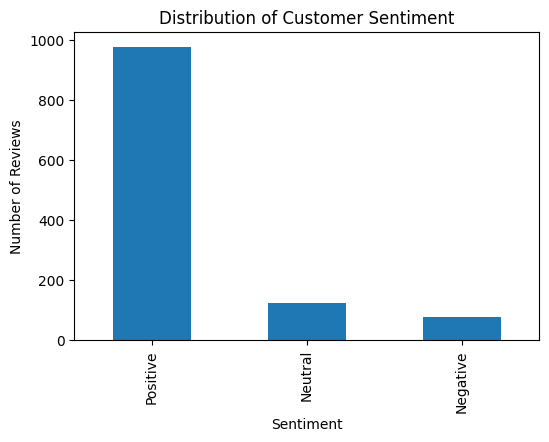

In [9]:
# ==========================================
# Section 8: Sentiment Distribution
# ==========================================

# Count each sentiment category
sentiment_counts = reviews_df["sentiment"].value_counts()

# Create a bar chart
plt.figure(figsize=(6,4))
sentiment_counts.plot(kind="bar")

plt.title("Distribution of Customer Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### Interpretation

The sentiment distribution shows that most customer reviews are positive, indicating generally high customer satisfaction with the Amazon products in this dataset. Neutral and negative reviews occur much less frequently, suggesting that future analysis should focus on identifying the common themes within these less frequent reviews to better understand customer concerns.

## 9. Text Preprocessing

The review text is cleaned to improve consistency before analysis. Text preprocessing includes converting text to lowercase, removing punctuation, removing numbers, and removing extra spaces.

In [10]:
# ==========================================
# Section 9: Text Preprocessing
# ==========================================

# Convert text to lowercase
reviews_df["clean_text"] = reviews_df["reviews.text"].str.lower()

# Remove punctuation
reviews_df["clean_text"] = reviews_df["clean_text"].str.replace(r"[^\w\s]", "", regex=True)

# Remove numbers
reviews_df["clean_text"] = reviews_df["clean_text"].str.replace(r"\d+", "", regex=True)

# Remove extra spaces
reviews_df["clean_text"] = reviews_df["clean_text"].str.replace(r"\s+", " ", regex=True)

print("Original Review:")
print(reviews_df["reviews.text"].iloc[0])

print("\n")

print("Cleaned Review:")
print(reviews_df["clean_text"].iloc[0])

Original Review:
I initially had trouble deciding between the paperwhite and the voyage because reviews more or less said the same thing: the paperwhite is great, but if you have spending money, go for the voyage.Fortunately, I had friends who owned each, so I ended up buying the paperwhite on this basis: both models now have 300 ppi, so the 80 dollar jump turns out pricey the voyage's page press isn't always sensitive, and if you are fine with a specific setting, you don't need auto light adjustment).It's been a week and I am loving my paperwhite, no regrets! The touch screen is receptive and easy to use, and I keep the light at a specific setting regardless of the time of day. (In any case, it's not hard to change the setting either, as you'll only be changing the light level at a certain time of day, not every now and then while reading).Also glad that I went for the international shipping option with Amazon. Extra expense, but delivery was on time, with tracking, and I didnt need t

## 10. Work Completed So Far

The following work has been completed for the project:

- Selected a new independent Amazon Product Reviews dataset from Kaggle.
- Defined the business problem and project objective.
- Imported the required Python libraries.
- Loaded and inspected the dataset.
- Selected the variables relevant to sentiment analysis.
- Identified and handled missing values.
- Created sentiment labels from customer ratings.
- Performed an initial exploratory analysis using a sentiment distribution chart.
- Preprocessed the review text by converting it to lowercase and removing punctuation, numbers, and extra spaces.

These steps provide a clean and well-structured dataset that is ready for more advanced text mining and machine learning techniques.

## 11. Preliminary Findings

After removing records with missing review text or ratings, 1,177 reviews remained for analysis. The sentiment distribution contains 977 positive reviews, 124 neutral reviews, and 76 negative reviews. This indicates that the dataset is strongly weighted toward positive customer feedback.

The imbalance between sentiment categories will need to be considered when evaluating future classification models because accuracy alone may provide a misleading picture of performance.

## 12. Remaining Work

The remaining work for this project includes:

- Perform additional exploratory analysis to identify common words and themes.
- Apply feature extraction techniques such as Bag-of-Words or TF-IDF.
- Train and evaluate sentiment classification models.
- Compare model performance using accuracy, precision, recall, and F1-score.
- Interpret the results from a business perspective.
- Complete the final report and presentation.
- Upload the completed notebook and supporting files to the project's public GitHub repository.

## 13. Current Limitations

- The dataset contains substantially more positive reviews than neutral or negative reviews.
- Star ratings are being used as approximate sentiment labels and may not always match the wording of the review.
- The dataset represents selected Amazon products and may not reflect all Amazon customers or product categories.
- Recommendation information contains many missing values and may only be used for optional analysis.

## 14. GitHub Repository

The project code, notebook, and supporting files will be maintained in a public GitHub repository and submitted with the final project.

GitHub Repository:
(To be added before final submission.)